In [ ]:
import json
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import math

from common import (
    CASE_NAMES,
    get_dataset_sort_key,
    INDEX_ORDER,
    index_colors,
    index_markers,
    transform_duckdb_index_name,
    transform_pgvector_index_name,
    apply_style,
    format_dataset_title,
    PLOT_DPI,
    LABEL_FONTSIZE,
    TICK_FONTSIZE,
    TITLE_FONTSIZE,
    MARKER_SIZE,
    FONT_COLOR,
    TICK_FONTS_COLOR,
)


def compute_qps(metrics: dict) -> float:
    """Compute QPS from serial_latencies (seconds)."""
    latencies = metrics.get("serial_latencies")
    if not latencies:
        raise ValueError("serial_latencies is missing or empty in metrics")
    return 1.0 / np.mean(latencies)


# ---------------------------------------------------------------------------
# 1. Load all result JSONs from the index_search results directory
# ---------------------------------------------------------------------------
records = []

# Load DuckDB results
duckdb_results_dir = pathlib.Path("../experiments/results/index_search/DuckDB")
duckdb_json_files = sorted(duckdb_results_dir.glob("*.json"))

for path in duckdb_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        metrics = entry["metrics"]
        task_cfg = entry["task_config"]
        db_cfg = task_cfg["db_config"]
        db_case_cfg = task_cfg["db_case_config"]
        case_cfg = task_cfg["case_config"]

        # Parse db_label JSON to get global_version
        db_label = json.loads(db_cfg.get("db_label", "{}"))
        global_version = db_label.get("global_version", None)

        index_name = transform_duckdb_index_name(db_case_cfg, global_version)

        records.append({
            "recall": metrics["recall"],
            "serial_qps": compute_qps(metrics),
            "index": index_name,
            "case_id": case_cfg["case_id"],
            "db_type": "DuckDB",
            "threads": db_cfg.get("duckdb_threads", 1),
        })

# Load pgvector results (if available)
pgvector_results_dir = pathlib.Path("../experiments/results/index_search/pgvector")
pgvector_json_files = sorted(pgvector_results_dir.glob("*.json")) if pgvector_results_dir.exists() else []

for path in pgvector_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        metrics = entry["metrics"]
        task_cfg = entry["task_config"]
        db_case_cfg = task_cfg["db_case_config"]
        case_cfg = task_cfg["case_config"]

        index_name = transform_pgvector_index_name(db_case_cfg)

        records.append({
            "recall": metrics["recall"],
            "serial_qps": compute_qps(metrics),
            "index": index_name,
            "case_id": case_cfg["case_id"],
            "db_type": "pgvector",
            "threads": db_case_cfg.get("max_parallel_workers", 1),
        })

print(f"Loaded {len(records)} results from {len(duckdb_json_files)} DuckDB files and {len(pgvector_json_files)} pgvector files")
records[:3]

Loaded 570 results from 475 DuckDB files and 95 pgvector files


[{'recall': 1.0,
  'serial_qps': np.float64(4.4079317039970105),
  'index': 'DuckDB',
  'case_id': 502,
  'db_type': 'DuckDB',
  'threads': 14},
 {'recall': 1.0,
  'serial_qps': np.float64(4.707855430483085),
  'index': 'DuckDB',
  'case_id': 501,
  'db_type': 'DuckDB',
  'threads': 14},
 {'recall': 0.9999,
  'serial_qps': np.float64(23.42619505468987),
  'index': 'DuckDB',
  'case_id': 503,
  'db_type': 'DuckDB',
  'threads': 14}]

In [2]:
# ---------------------------------------------------------------------------
# 2. Case ID → human-readable dataset name
# ---------------------------------------------------------------------------

for r in records:
    r["dataset"] = CASE_NAMES.get(r["case_id"], f"Unknown (case_id={r['case_id']})")

unique_datasets = set(r["dataset"] for r in records)
datasets = sorted(unique_datasets, key=get_dataset_sort_key)

Single-thread records: 200, Multi-thread records: 370


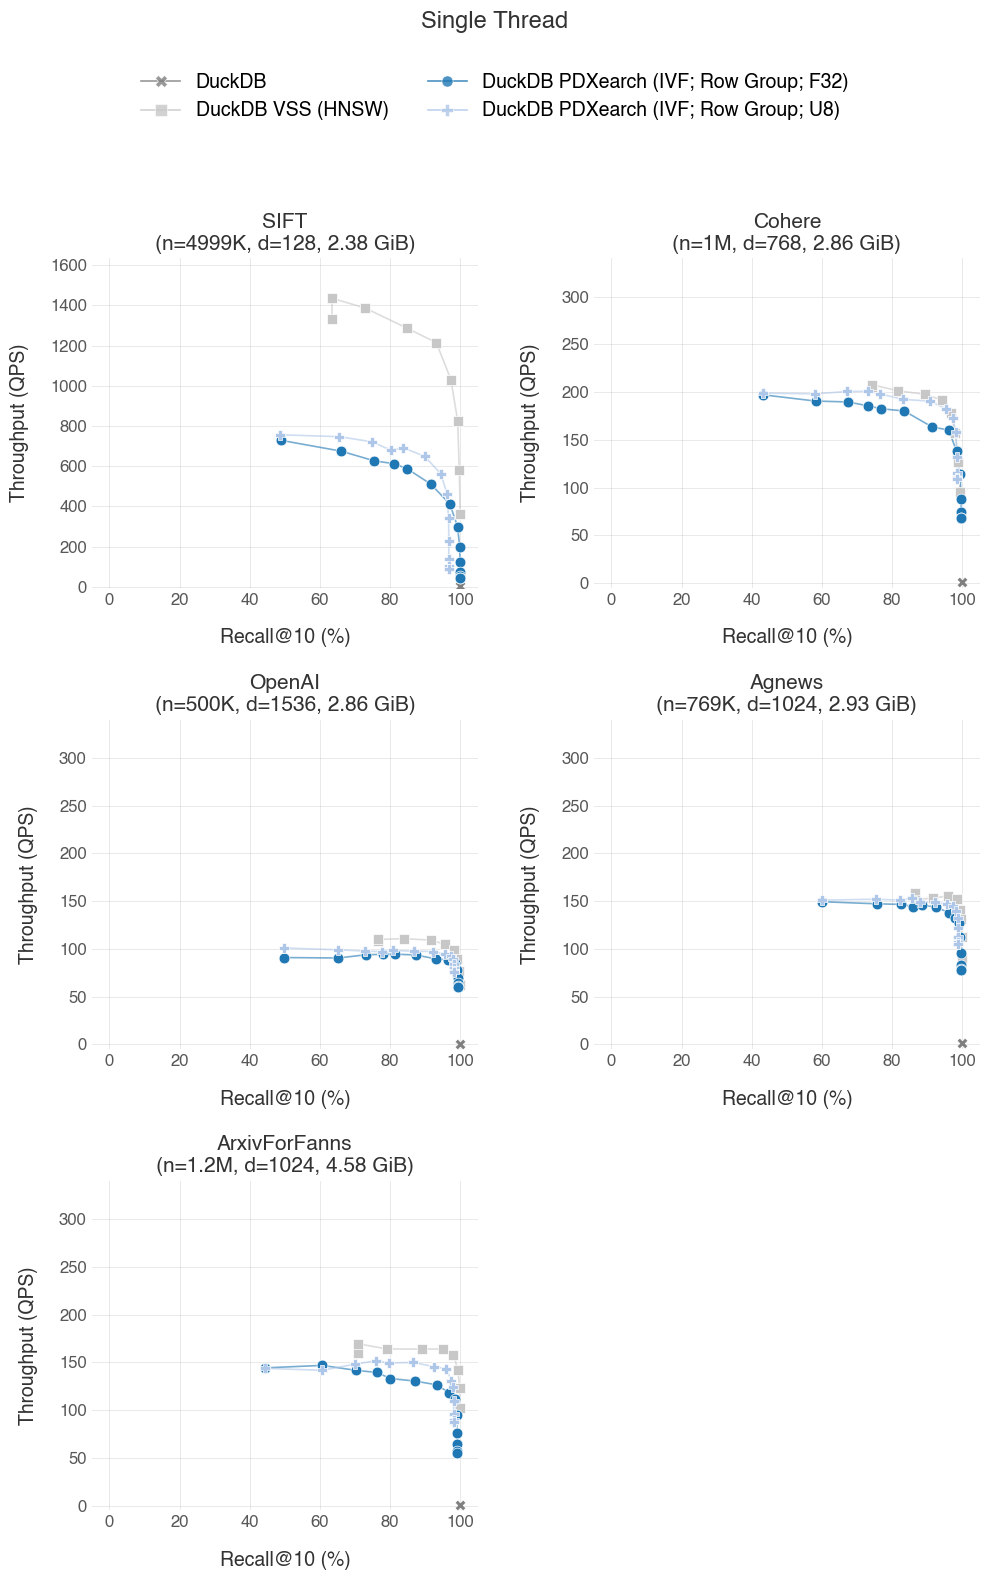

Saved index_search_single_thread.pdf


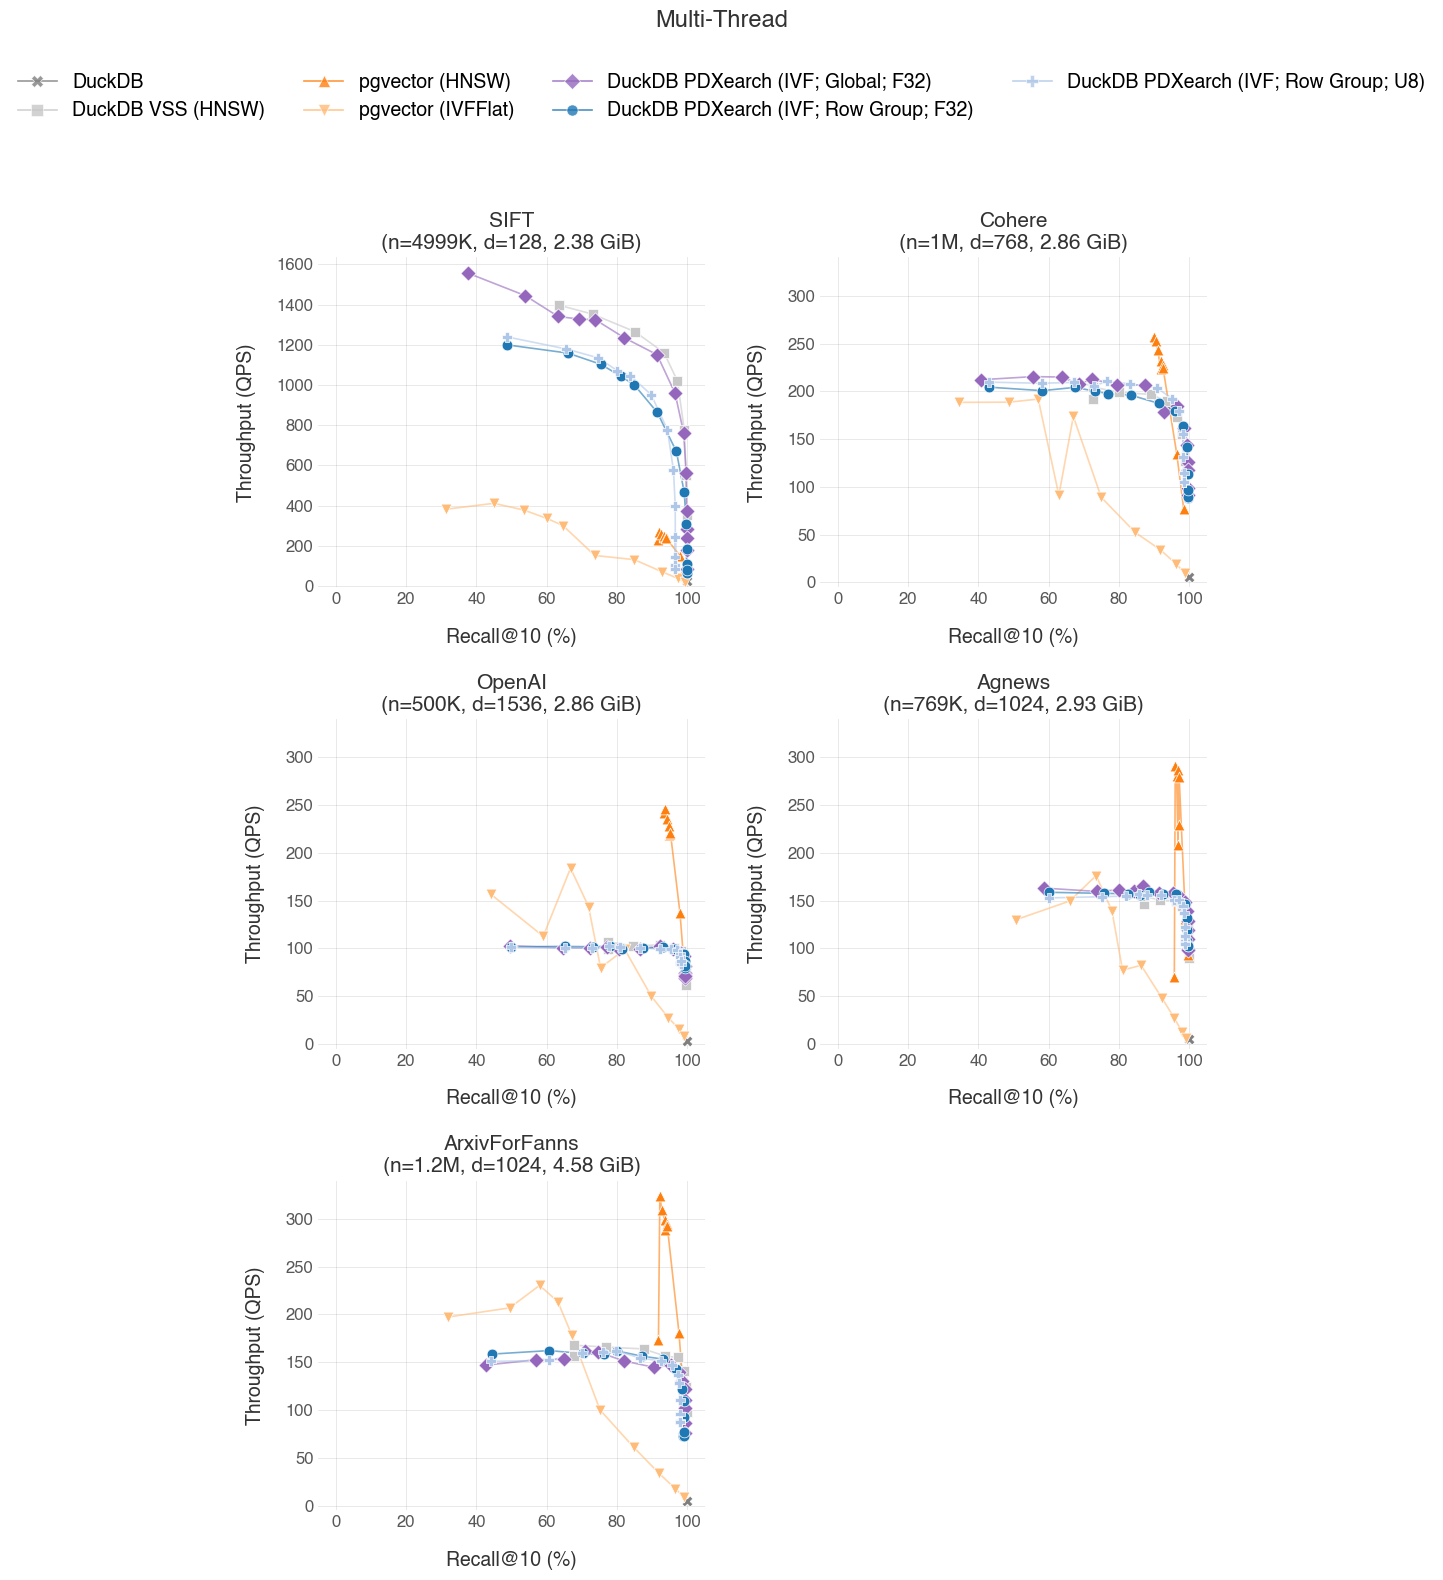

Saved index_search_multi_thread.pdf


In [3]:
# ---------------------------------------------------------------------------
# 3. Scatter plot: Recall vs QPS, one subplot per dataset
#    Separate figures for single-thread (threads=1) vs multi-thread (threads>1)
# ---------------------------------------------------------------------------
from collections import defaultdict
import re
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D

apply_style()


def compute_shared_ylims(all_records, datasets):
    """Compute y-axis limits from *all* records so separate plots share the same scale."""
    per_dataset_qps: dict[str, list[float]] = defaultdict(list)
    non_sift_qps: list[float] = []
    for r in all_records:
        ds = r["dataset"]
        qps = r["serial_qps"]
        per_dataset_qps[ds].append(qps)
        if "SIFT" not in ds:
            non_sift_qps.append(qps)

    non_sift_y_max = max(non_sift_qps) if non_sift_qps else 1
    non_sift_ylim = (-0.05, non_sift_y_max * 1.05)

    ylims: dict[str, tuple[float, float]] = {}
    for ds in datasets:
        if "SIFT" in ds:
            ds_max = max(per_dataset_qps[ds]) if per_dataset_qps[ds] else 1
            ylims[ds] = (-0.05, ds_max * 1.05)
        else:
            ylims[ds] = non_sift_ylim
    return ylims


shared_ylims = compute_shared_ylims(records, datasets)


def plot_recall_vs_qps(subset_records, datasets, filename, suptitle=None, ylims=None):
    """Plot Recall vs QPS scatter with one subplot per dataset, saving to *filename*."""
    grouped: dict[str, dict[str, list[tuple[float, float]]]] = defaultdict(lambda: defaultdict(list))
    for r in subset_records:
        grouped[r["dataset"]][r["index"]].append((r["recall"], r["serial_qps"]))

    present_datasets = [ds for ds in datasets if grouped[ds]]
    if not present_datasets:
        print(f"No data for {filename}, skipping.")
        return

    all_index_types = set()
    for dataset in present_datasets:
        all_index_types.update(grouped[dataset].keys())
    all_index_types = [idx for idx in INDEX_ORDER if idx in all_index_types]

    n_datasets = len(present_datasets)
    n_cols = min(n_datasets, 2)
    n_rows = (n_datasets + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows), squeeze=False)

    for ds_idx, dataset in enumerate(present_datasets):
        row, col = divmod(ds_idx, n_cols)
        ax = axes[row][col]

        for index_type in all_index_types:
            points = grouped[dataset].get(index_type, [])
            if not points:
                continue

            points.sort(key=lambda p: p[0])
            recalls = [p[0] for p in points]
            qps_vals = [p[1] for p in points]

            color = index_colors.get(index_type, "#808080")
            marker = index_markers.get(index_type, "o")

            ax.scatter(recalls, qps_vals, label=index_type, color=color,
                       marker=marker, s=MARKER_SIZE, zorder=3, edgecolors='white', linewidths=0.5)
            ax.plot(recalls, qps_vals, color=color, linewidth=1.2, alpha=0.6, zorder=2)

        ax.set_title(format_dataset_title(dataset), fontsize=TITLE_FONTSIZE, color=FONT_COLOR)
        ax.set_xlabel("Recall@10 (%)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)
        ax.set_ylabel("Throughput (QPS)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)

        ax.grid(True, linestyle='-', linewidth=0.6, color='gray', alpha=0.2)
        ax.set_axisbelow(True)
        ax.set_xticks([i / 5 for i in range(6)])
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x * 100:.0f}"))

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

        ax.set_xlim(-0.05, 1.05)
        if ylims and dataset in ylims:
            ax.set_ylim(-5, ylims[dataset][1])

        ax.tick_params(axis='both', colors=TICK_FONTS_COLOR, length=0)
        ax.tick_params(axis='x', labelsize=TICK_FONTSIZE)
        ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)

    for idx in range(n_datasets, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row][col].set_visible(False)

    legend_handles = []
    for index_type in all_index_types:
        color = index_colors.get(index_type, "#808080")
        marker = index_markers.get(index_type, "o")
        legend_handles.append(Line2D([0], [0], color=color, marker=marker, linestyle='-',
                                      markersize=8, markeredgecolor='white', markeredgewidth=0.5,
                                      linewidth=1.2, alpha=0.8, label=index_type))

    fig.legend(handles=legend_handles, loc="upper center", ncol=math.ceil(len(all_index_types) / 2),
               frameon=False, fontsize=LABEL_FONTSIZE, bbox_to_anchor=(0.5, 1.02))

    if suptitle:
        fig.suptitle(suptitle, fontsize=TITLE_FONTSIZE + 2, color=FONT_COLOR, y=1.05)

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.subplots_adjust(wspace=0.30, hspace=0.40)
    plt.savefig(filename, dpi=PLOT_DPI, bbox_inches='tight')
    plt.show()
    print(f"Saved {filename}")


records_single = [r for r in records if r["threads"] == 1]
records_multi = [r for r in records if r["threads"] > 1]

print(f"Single-thread records: {len(records_single)}, Multi-thread records: {len(records_multi)}")

plot_recall_vs_qps(records_single, datasets, "index_search_single_thread.pdf",
                   suptitle="Single Thread", ylims=shared_ylims)
plot_recall_vs_qps(records_multi, datasets, "index_search_multi_thread.pdf",
                   suptitle="Multi-Thread", ylims=shared_ylims)

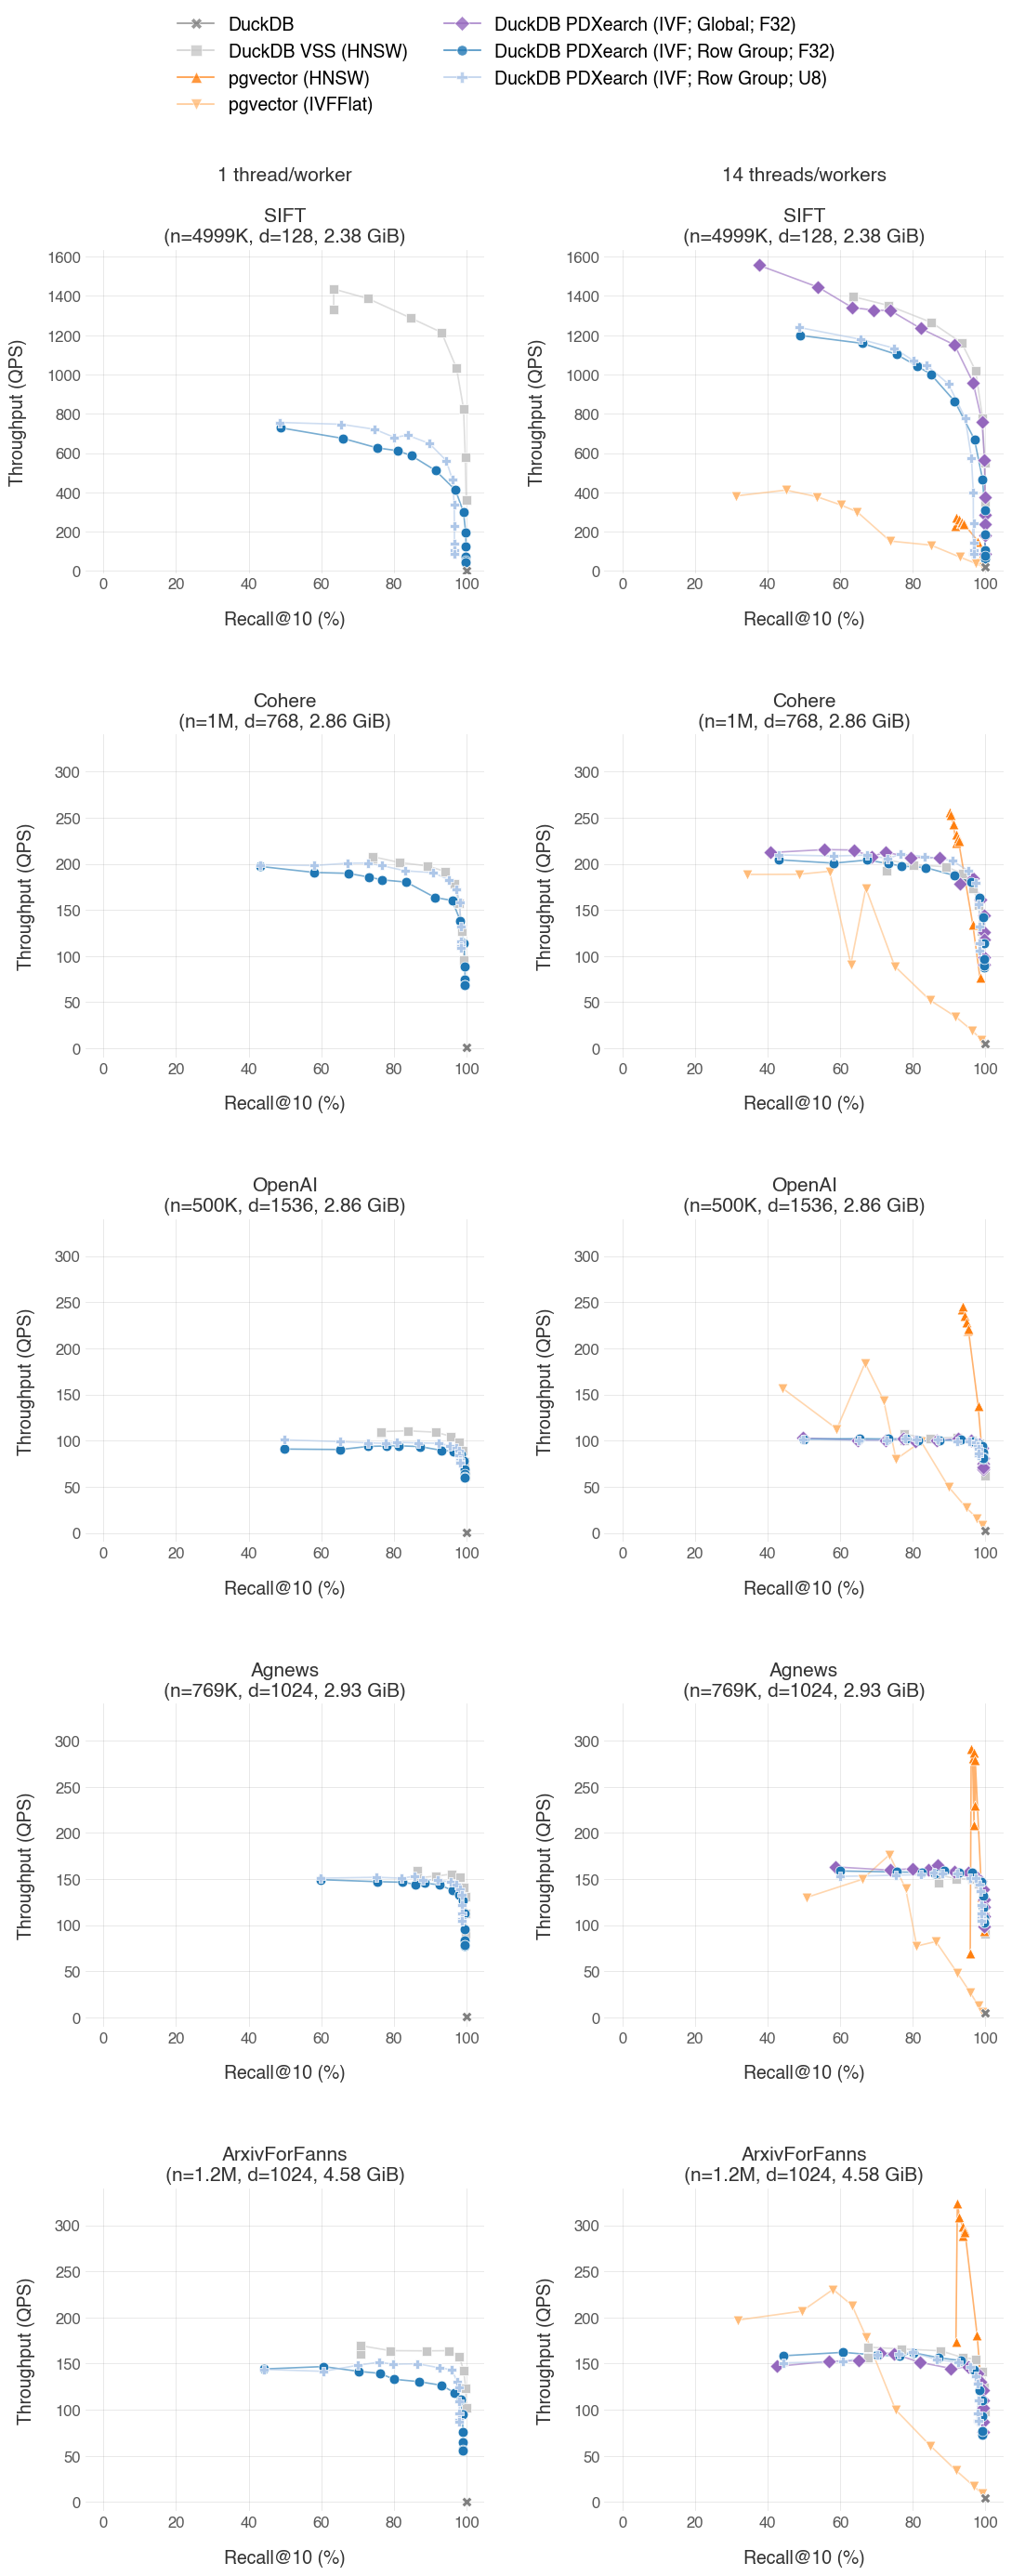

Saved index_search_combined.pdf


In [4]:
# ---------------------------------------------------------------------------
# 4. Combined side-by-side: single-thread (left) vs multi-thread (right)
#    5 rows (one per dataset) × 2 columns
# ---------------------------------------------------------------------------
apply_style()

thread_groups = [
    ("1 thread/worker", records_single),
    ("14 threads/workers", records_multi),
]

# Build grouped data for each thread group
grouped_by_thread: list[dict[str, dict[str, list[tuple[float, float]]]]] = []
all_index_types_combined = set()
for _, recs in thread_groups:
    g: dict[str, dict[str, list[tuple[float, float]]]] = defaultdict(lambda: defaultdict(list))
    for r in recs:
        g[r["dataset"]][r["index"]].append((r["recall"], r["serial_qps"]))
    grouped_by_thread.append(g)
    for ds in datasets:
        all_index_types_combined.update(g[ds].keys())
all_index_types_combined = [idx for idx in INDEX_ORDER if idx in all_index_types_combined]

n_rows = len(datasets)
n_cols = len(thread_groups)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 5.5 * n_rows), squeeze=False)

for col_idx, (col_title, _) in enumerate(thread_groups):
    grouped = grouped_by_thread[col_idx]

    for row_idx, dataset in enumerate(datasets):
        ax = axes[row_idx][col_idx]

        for index_type in all_index_types_combined:
            points = grouped[dataset].get(index_type, [])
            if not points:
                continue
            points.sort(key=lambda p: p[0])
            recalls = [p[0] for p in points]
            qps_vals = [p[1] for p in points]

            z_scatter = 10 if index_type == "DuckDB" else 3
            z_line = 9 if index_type == "DuckDB" else 2

            color = index_colors.get(index_type, "#808080")
            marker = index_markers.get(index_type, "o")

            ax.scatter(recalls, qps_vals, label=index_type, color=color,
                       marker=marker, s=MARKER_SIZE, zorder=z_scatter, edgecolors='white', linewidths=0.5)
            ax.plot(recalls, qps_vals, color=color, linewidth=1.2, alpha=0.6, zorder=z_line)

        title = format_dataset_title(dataset)
        if row_idx == 0:
            title = f"{col_title}\n\n{title}"
        ax.set_title(title, fontsize=TITLE_FONTSIZE, color=FONT_COLOR)
        ax.set_xlabel("Recall@10 (%)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)
        ax.set_ylabel("Throughput (QPS)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)

        ax.grid(True, linestyle='-', linewidth=0.6, color='gray', alpha=0.2)
        ax.set_axisbelow(True)
        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-10, shared_ylims[dataset][1])
        ax.set_xticks([i / 5 for i in range(6)])
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x * 100:.0f}"))

        ax.tick_params(axis='both', colors=TICK_FONTS_COLOR, length=0)
        ax.tick_params(axis='x', labelsize=TICK_FONTSIZE)
        ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)

legend_handles = []
for index_type in all_index_types_combined:
    color = index_colors.get(index_type, "#808080")
    marker = index_markers.get(index_type, "o")
    legend_handles.append(Line2D([0], [0], color=color, marker=marker, linestyle='-',
                                  markersize=8, markeredgecolor='white', markeredgewidth=0.5,
                                  linewidth=1.2, alpha=0.8, label=index_type))

fig.legend(handles=legend_handles, loc="upper center", ncol=math.ceil(len(all_index_types_combined) / 4),
           frameon=False, fontsize=LABEL_FONTSIZE, bbox_to_anchor=(0.5, 1.01))

fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.subplots_adjust(wspace=0.30, hspace=0.50)
plt.savefig("index_search_combined.pdf", dpi=PLOT_DPI, bbox_inches='tight')
plt.show()
print("Saved index_search_combined.pdf")

Cohere multi-thread records: 74


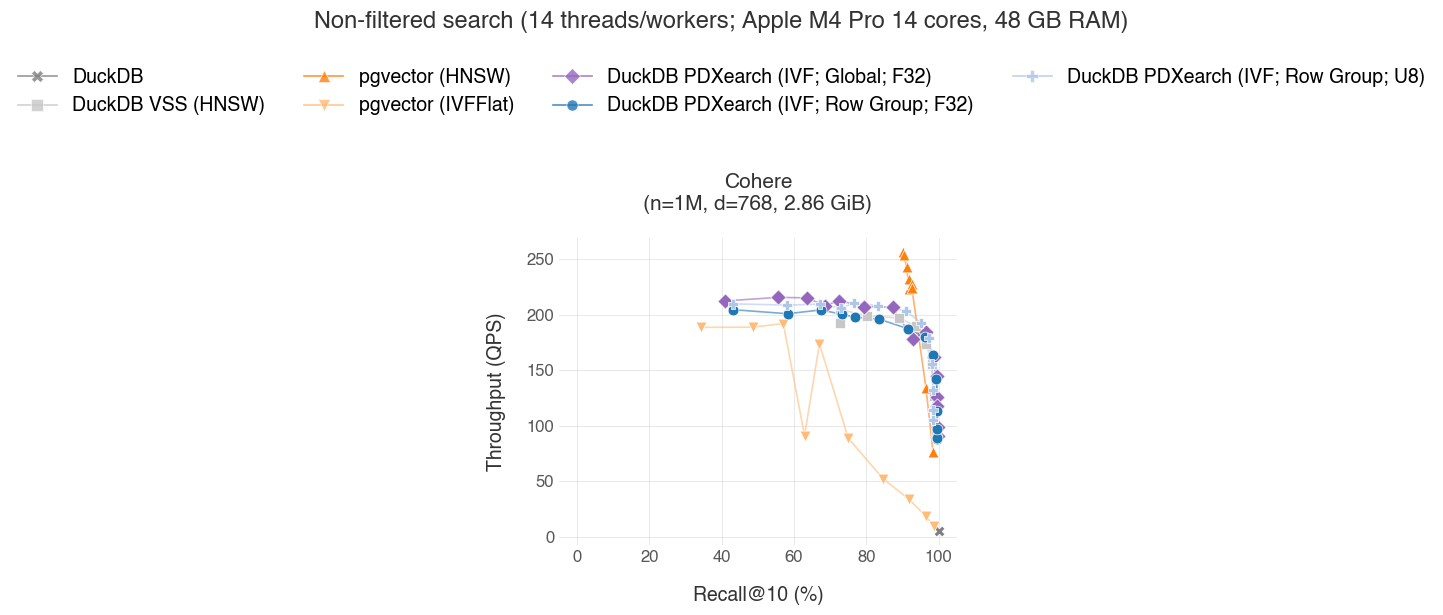

Saved index_search_cohere_multi_thread.pdf


In [5]:
# ---------------------------------------------------------------------------
# 5. Multi-thread Cohere only (standalone plot with own y-axis range)
# ---------------------------------------------------------------------------
from collections import defaultdict
from matplotlib.lines import Line2D

apply_style()

cohere_multi = [r for r in records if r["threads"] > 1 and "Cohere" in r["dataset"]]
cohere_datasets = [ds for ds in datasets if "Cohere" in ds]
print(f"Cohere multi-thread records: {len(cohere_multi)}")

grouped: dict[str, dict[str, list[tuple[float, float]]]] = defaultdict(lambda: defaultdict(list))
for r in cohere_multi:
    grouped[r["dataset"]][r["index"]].append((r["recall"], r["serial_qps"]))

present_datasets = [ds for ds in cohere_datasets if grouped[ds]]

all_index_types = set()
for ds in present_datasets:
    all_index_types.update(grouped[ds].keys())
all_index_types = [idx for idx in INDEX_ORDER if idx in all_index_types]

n_datasets = len(present_datasets)
fig, axes = plt.subplots(1, n_datasets, figsize=(5 * n_datasets, 5), squeeze=False)

for ds_idx, dataset in enumerate(present_datasets):
    ax = axes[0][ds_idx]

    for index_type in all_index_types:
        points = grouped[dataset].get(index_type, [])
        if not points:
            continue
        points.sort(key=lambda p: p[0])
        recalls = [p[0] for p in points]
        qps_vals = [p[1] for p in points]

        color = index_colors.get(index_type, "#808080")
        marker = index_markers.get(index_type, "o")
        ax.scatter(recalls, qps_vals, color=color, marker=marker, s=MARKER_SIZE,
                   zorder=3, edgecolors='white', linewidths=0.5)
        ax.plot(recalls, qps_vals, color=color, linewidth=1.2, alpha=0.6, zorder=2)

    ax.set_title(format_dataset_title(dataset), fontsize=TITLE_FONTSIZE, color=FONT_COLOR, pad=20)
    ax.set_xlabel("Recall@10 (%)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)
    ax.set_ylabel("Throughput (QPS)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)

    ax.grid(True, linestyle='-', linewidth=0.6, color='gray', alpha=0.2)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xlim(-0.05, 1.05)
    ax.set_xticks([i / 5 for i in range(6)])
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x * 100:.0f}"))
    ax.tick_params(axis='both', colors=TICK_FONTS_COLOR, length=0)
    ax.tick_params(axis='x', labelsize=TICK_FONTSIZE)
    ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)

legend_handles = []
for index_type in all_index_types:
    color = index_colors.get(index_type, "#808080")
    marker = index_markers.get(index_type, "o")
    legend_handles.append(Line2D([0], [0], color=color, marker=marker, linestyle='-',
                                  markersize=8, markeredgecolor='white', markeredgewidth=0.5,
                                  linewidth=1.2, alpha=0.8, label=index_type))

fig.legend(handles=legend_handles, loc="upper center", ncol=math.ceil(len(all_index_types) / 2),
           frameon=False, fontsize=LABEL_FONTSIZE, bbox_to_anchor=(0.5, 1.14))

fig.suptitle("Non-filtered search (14 threads/workers; Apple M4 Pro 14 cores, 48 GB RAM)",
             fontsize=TITLE_FONTSIZE + 2, color=FONT_COLOR, y=1.22)

fig.tight_layout(rect=[0, 0, 1, 1])
plt.savefig("index_search_cohere_multi_thread.pdf", dpi=PLOT_DPI, bbox_inches='tight')
plt.show()
print("Saved index_search_cohere_multi_thread.pdf")